In [1]:
# 1) ensure Python can see your project root
import os, sys, time
import numpy as np
import matplotlib.pyplot as plt

project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
if project_root not in sys.path:
    sys.path.insert(0, project_root)

print("→ Added to sys.path:", project_root)
print("→ cwd is:", os.getcwd())

from environments.auv_env.auv_env    import AUVEnv
from environments.auv_env.auv_config import AUVEnvConfig
from agents.auv_dqn_agent    import AuvDQNAgent
from agents.dqn_agent      import train_dqn
from environments.grid_env.grid_utils     import plot_rewards, evaluate_agent
from utils.graphics_utils import record_headless

→ Added to sys.path: /Users/eirikvarnes/code/auv-rl-project
→ cwd is: /Users/eirikvarnes/code/auv-rl-project/notebooks
pygame 2.6.1 (SDL 2.28.4, Python 3.11.12)
Hello from the pygame community. https://www.pygame.org/contribute.html


In [2]:
static_cfg = AUVEnvConfig(n_beams=20)
static_env = AUVEnv(static_cfg)

static_agent = AuvDQNAgent(
    static_env,
    hidden_dims=[64,64],
    lr=1e-3,
    gamma=0.95,
    epsilon_start=1.0,
    epsilon_min=0.01,
    epsilon_decay=0.995,
    batch_size=64,
    buffer_size=5000,
    target_update=20,
)


In [ ]:
rewards = train_dqn(static_env, static_agent, episodes=1000, max_steps= 500)
plot_rewards(rewards, window=50)
static_agent.save("../models/static_auv_dqn.pth")

DQN Training:  25%|██▍       | 248/1000 [01:08<02:18,  5.45it/s, Reward=90.1, ε=0.288]  

In [ ]:
static_agent.load("../models/static_auv_dqn.pth")

In [ ]:
record_headless(static_env, static_agent, out_path='../gifs/static_auv.gif')

Headless recording saved to ../gifs/static_auv.gif


In [ ]:
sr, avg_steps = evaluate_agent(static_env, static_agent, episodes = 500, max_steps=500)
print(f"Success rate: {sr*100:.1f}%, Avg steps: {avg_steps:.1f}")

In [ ]:
random_cfg = AUVEnvConfig(random_map=True)
random_env = AUVEnv(random_cfg)

random_agent = AuvDQNAgent(
    random_env,
    hidden_dims=[64,64],
    lr=1e-3,
    gamma=0.95,
    epsilon_start=1.0,
    epsilon_min=0.01,
    epsilon_decay=0.995,
    batch_size=64,
    buffer_size=5000,
    target_update=20,
)


DQN Training: 100%|██████████| 1000/1000 [42:58<00:00,  2.58s/it, Reward=-11.1, ε=0.010]     


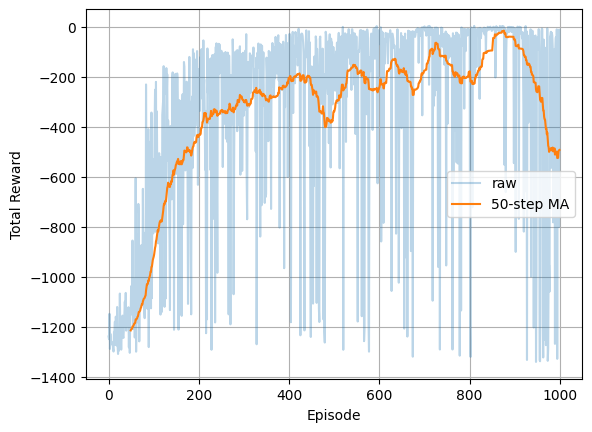

In [ ]:
rewards = train_dqn(random_env, random_agent, episodes=1000, max_steps= 500)
plot_rewards(rewards, window=50)
random_agent.save("../models/static_auv_dqn.pth")

In [ ]:
record_headless(random_env, random_agent, out_path='../gifs/random_auv.gif')

Headless recording saved to ../gifs/random_auv.gif


In [ ]:
sr, avg_steps = evaluate_agent(random_env, random_agent, episodes = 500, max_steps=200)
print(f"Success rate: {sr*100:.1f}%, Avg steps: {avg_steps:.1f}")

Success rate: 100.0%, Avg steps: 74.0
